# CAVE / TEASAR skeleton agreement versus Casey confidence

Each point represents one matched cell, comparing the two full skeletons under
the same v1718 root. Casey's identity and confidence come from the existing
root/nucleus join. Confidence describes **cell-type annotation confidence**;
the geometry metrics describe agreement between skeletonization methods.

The default uses Casey **coarse confidence** and **coarse cell type**. Change
the configuration to fine confidence/fine type or your original classification.
No confidence threshold or additional cell-type filter is applied.

Mean distance is lower for closer centerlines; overlap F1 is higher for greater
agreement. A cable-length ratio of 1 means equal total cable. Distances are exact
to target segments, with cable-weighted source integration at 250 nm spacing
(mean quadrature bound: 125 nm).

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "scripts/compare_skeleton_geometry.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.presynaptic.skeleton_comparison import geometry_confidence as gc

METRICS_CSV = gc.DEFAULT_CSV
CONFIDENCE_COLUMN = "casey_coarse_confidence"  # or "casey_fine_confidence"
CELL_TYPE_COLUMN = "casey_coarse"  # or "casey_fine", "cell_classification"
CONFIDENCE_LABEL = CONFIDENCE_COLUMN.replace("_", " ").capitalize()
METRICS = gc.DEFAULT_METRICS.copy()
# Optional additional panels, using any numeric column in metrics.csv:
# METRICS["precision_1um"] = "TEASAR cable coverage at 1 µm"
# METRICS["recall_1um"] = "CAVE cable coverage at 1 µm"
# METRICS["cave_p95_um"] = "CAVE → TEASAR 95th percentile distance (µm)"
BINS = 10
EXPORT = True
FIGURE_DIR = ROOT / "analysis/presynaptic/skeleton_comparison/geometry_confidence_figures" / f"{CONFIDENCE_COLUMN}__{CELL_TYPE_COLUMN}"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

cells, audit = gc.load_metrics(METRICS_CSV, CONFIDENCE_COLUMN, CELL_TYPE_COLUMN)
display(audit.to_frame())
display(cells.groupby("cell_type").agg(
    cells=("root_id", "size"), median_confidence=("confidence", "median"),
    min_confidence=("confidence", "min"), max_confidence=("confidence", "max")))

,count
CSV rows,2069
successful cells,2069
successful cells missing/invalid confidence,1
plotted cells,2068


,cells,median_confidence,min_confidence,max_confidence
cell_type,,,,
BasketFam,171,1.00,0.30,1.0
BipFam,127,1.00,0.20,1.0
ChC,1,0.80,0.80,0.8
L2,234,0.95,0.15,1.0
L3,253,0.90,0.10,1.0
L4,551,1.00,0.10,1.0
L5,127,0.95,0.00,1.0
L5ET,53,1.00,0.15,1.0
L5NP,10,0.95,0.60,1.0


## Global plots

All cells have equal weight. Color indicates the selected cell type. Black
points/lines show medians in ten equal-width confidence bins (empty bins are
omitted), placed at the median confidence of cells in each bin. Confidence 1
belongs to the final bin. Confidence values are not jittered. Annotations show
sample size and Spearman rank correlation; correlation is undefined when a
variable is constant or there are fewer than three cells. Pooled correlations
can reflect differences in cell-type composition. Overlap and cable-ratio
axes span the observed values to show variation; their y axes need not start
at zero. All observations, including distance outliers, remain visible.

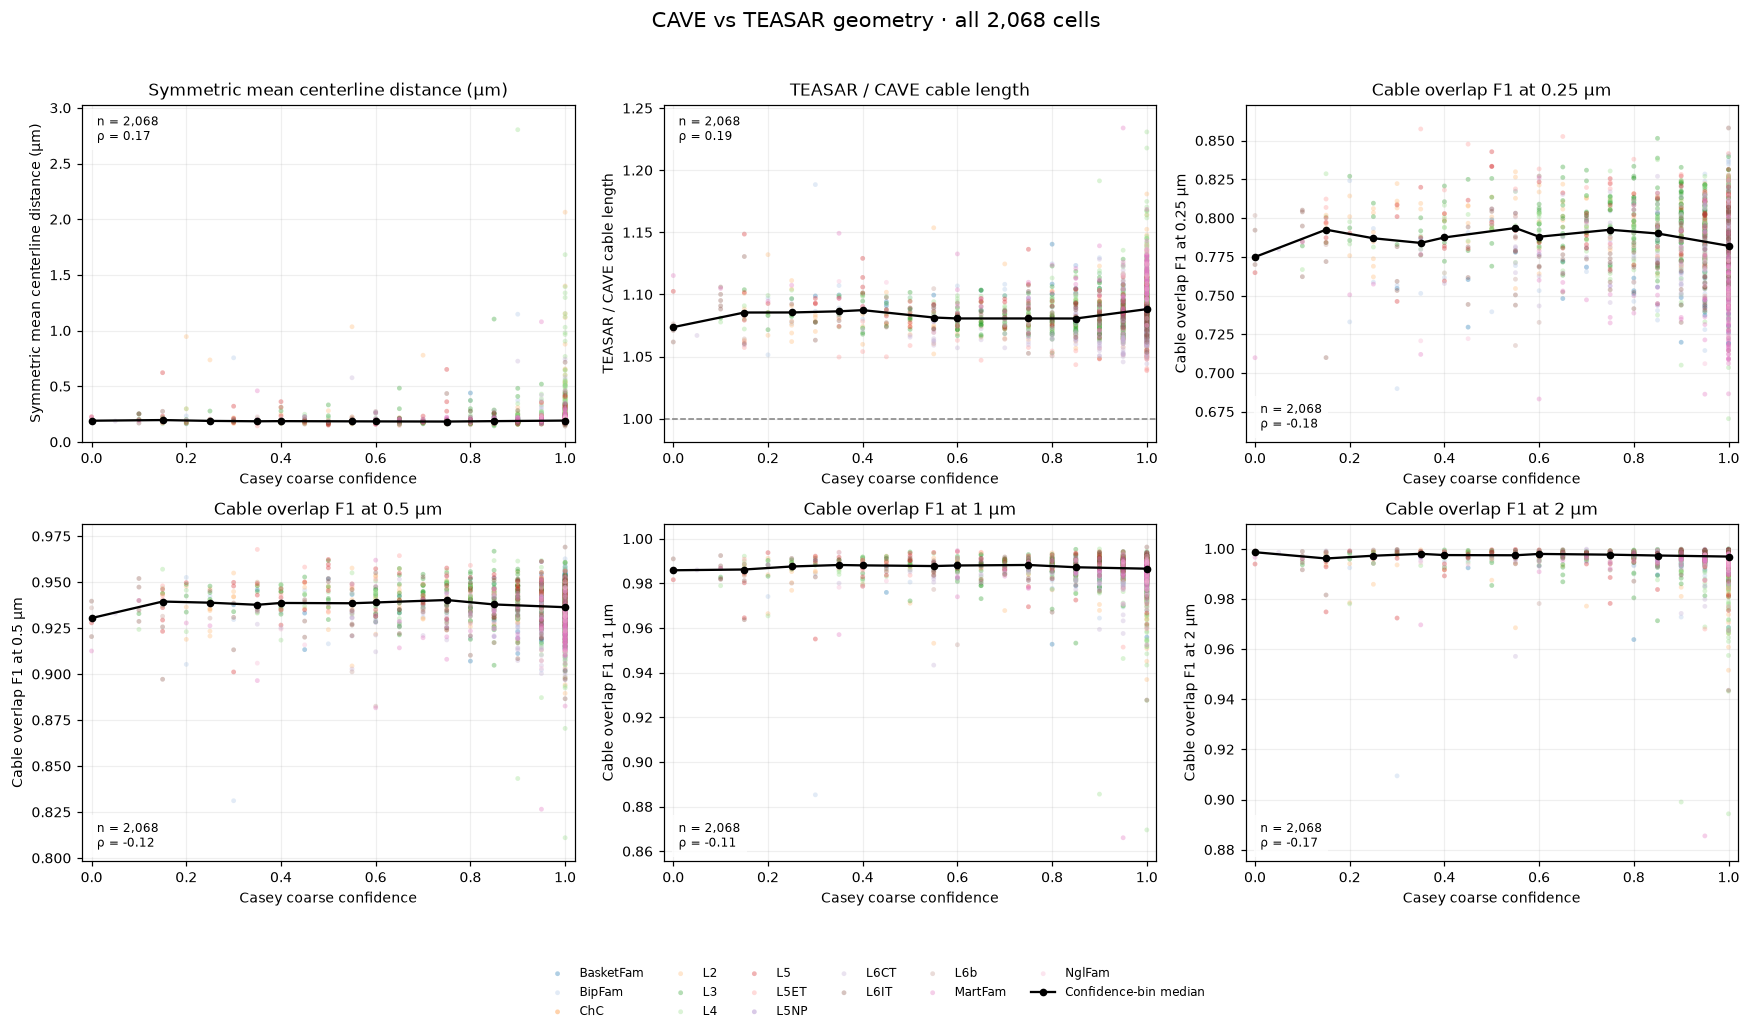

In [2]:
fig = gc.plot_global(cells, METRICS, CONFIDENCE_LABEL, BINS)
if EXPORT:
    gc.save_figure(fig, FIGURE_DIR, "global")
plt.show()
plt.close(fig)

## Plots by cell type

One figure per metric, with a panel for every observed cell type. Each figure
shares the same x/y scales across types to allow direct comparison. Black lines
and correlation annotations are computed separately within each type. Small
groups and types with little confidence variation remain visible.

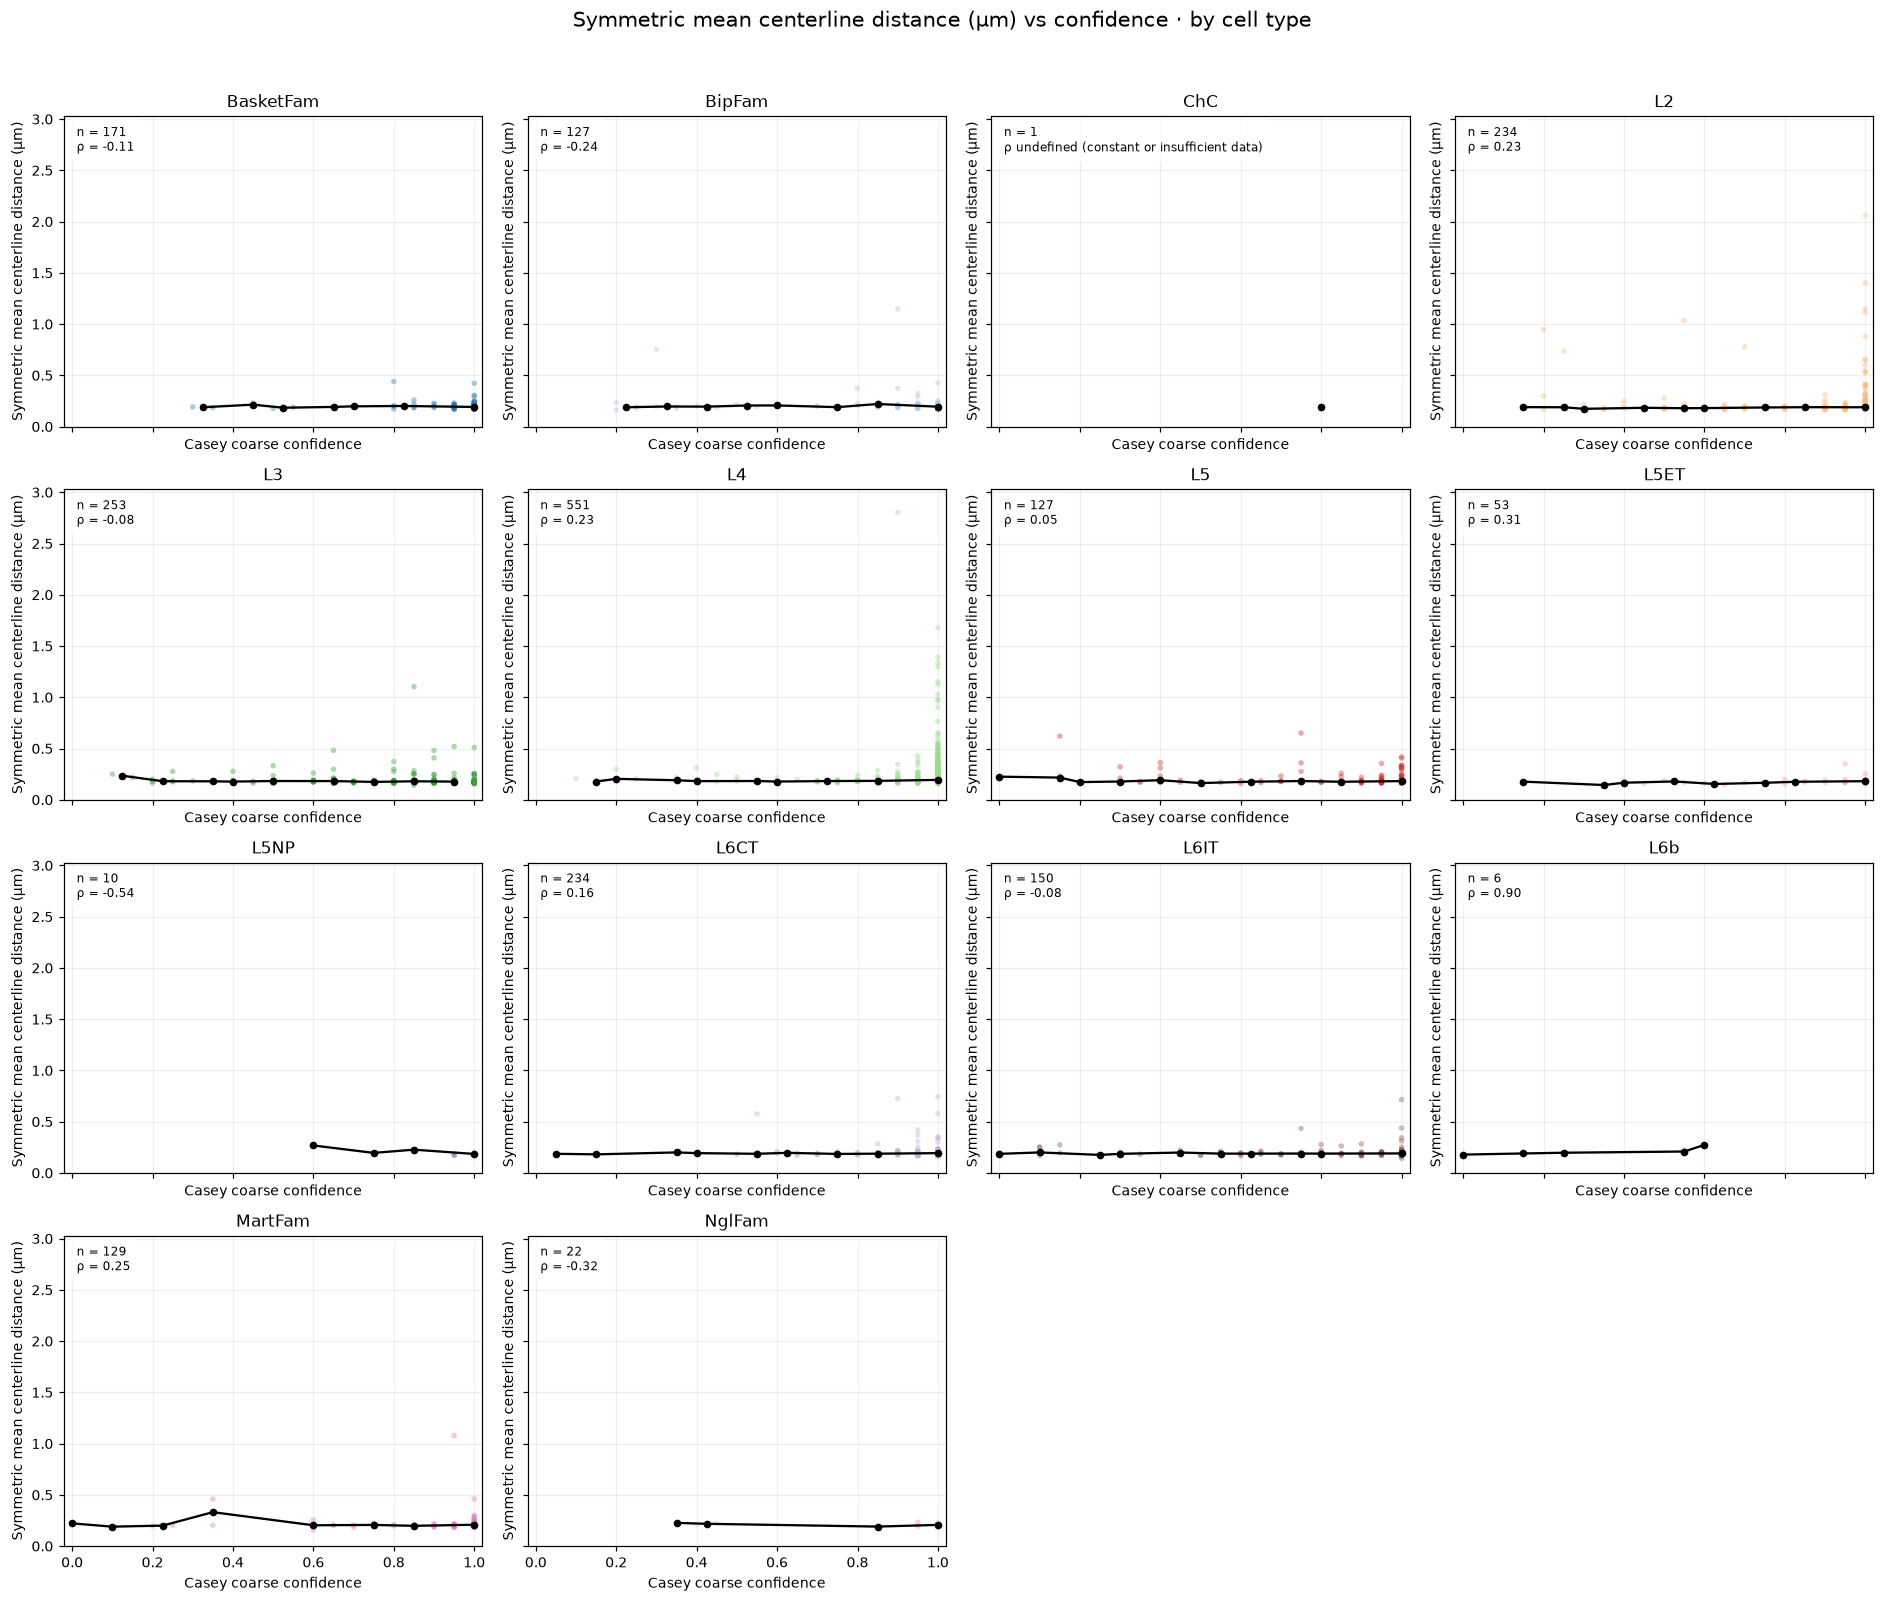

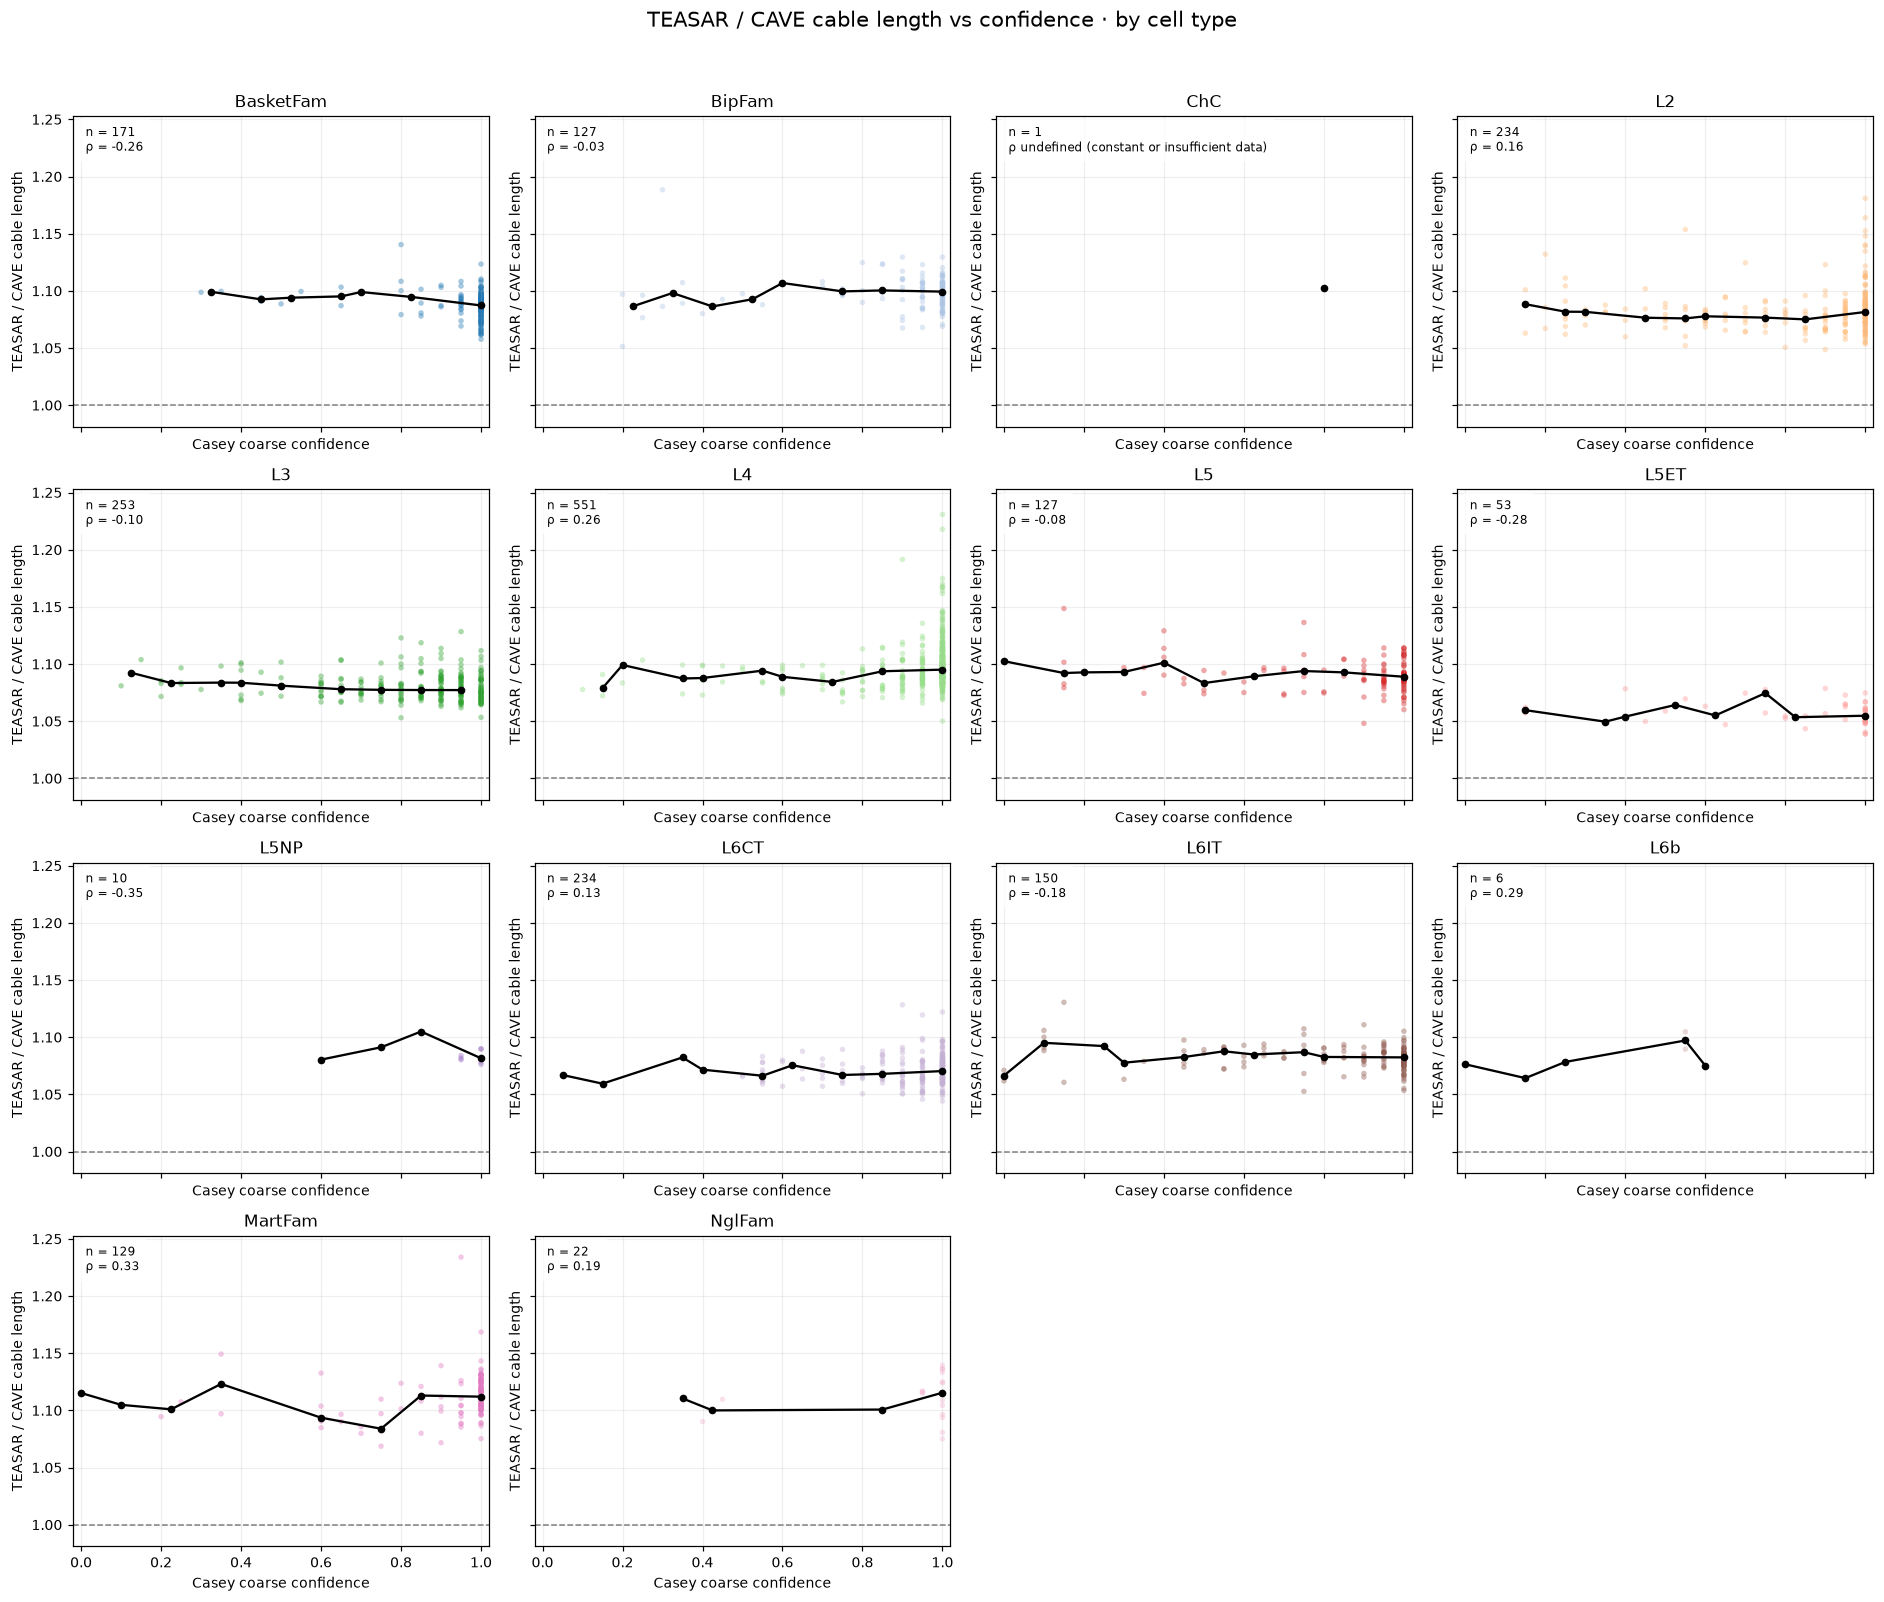

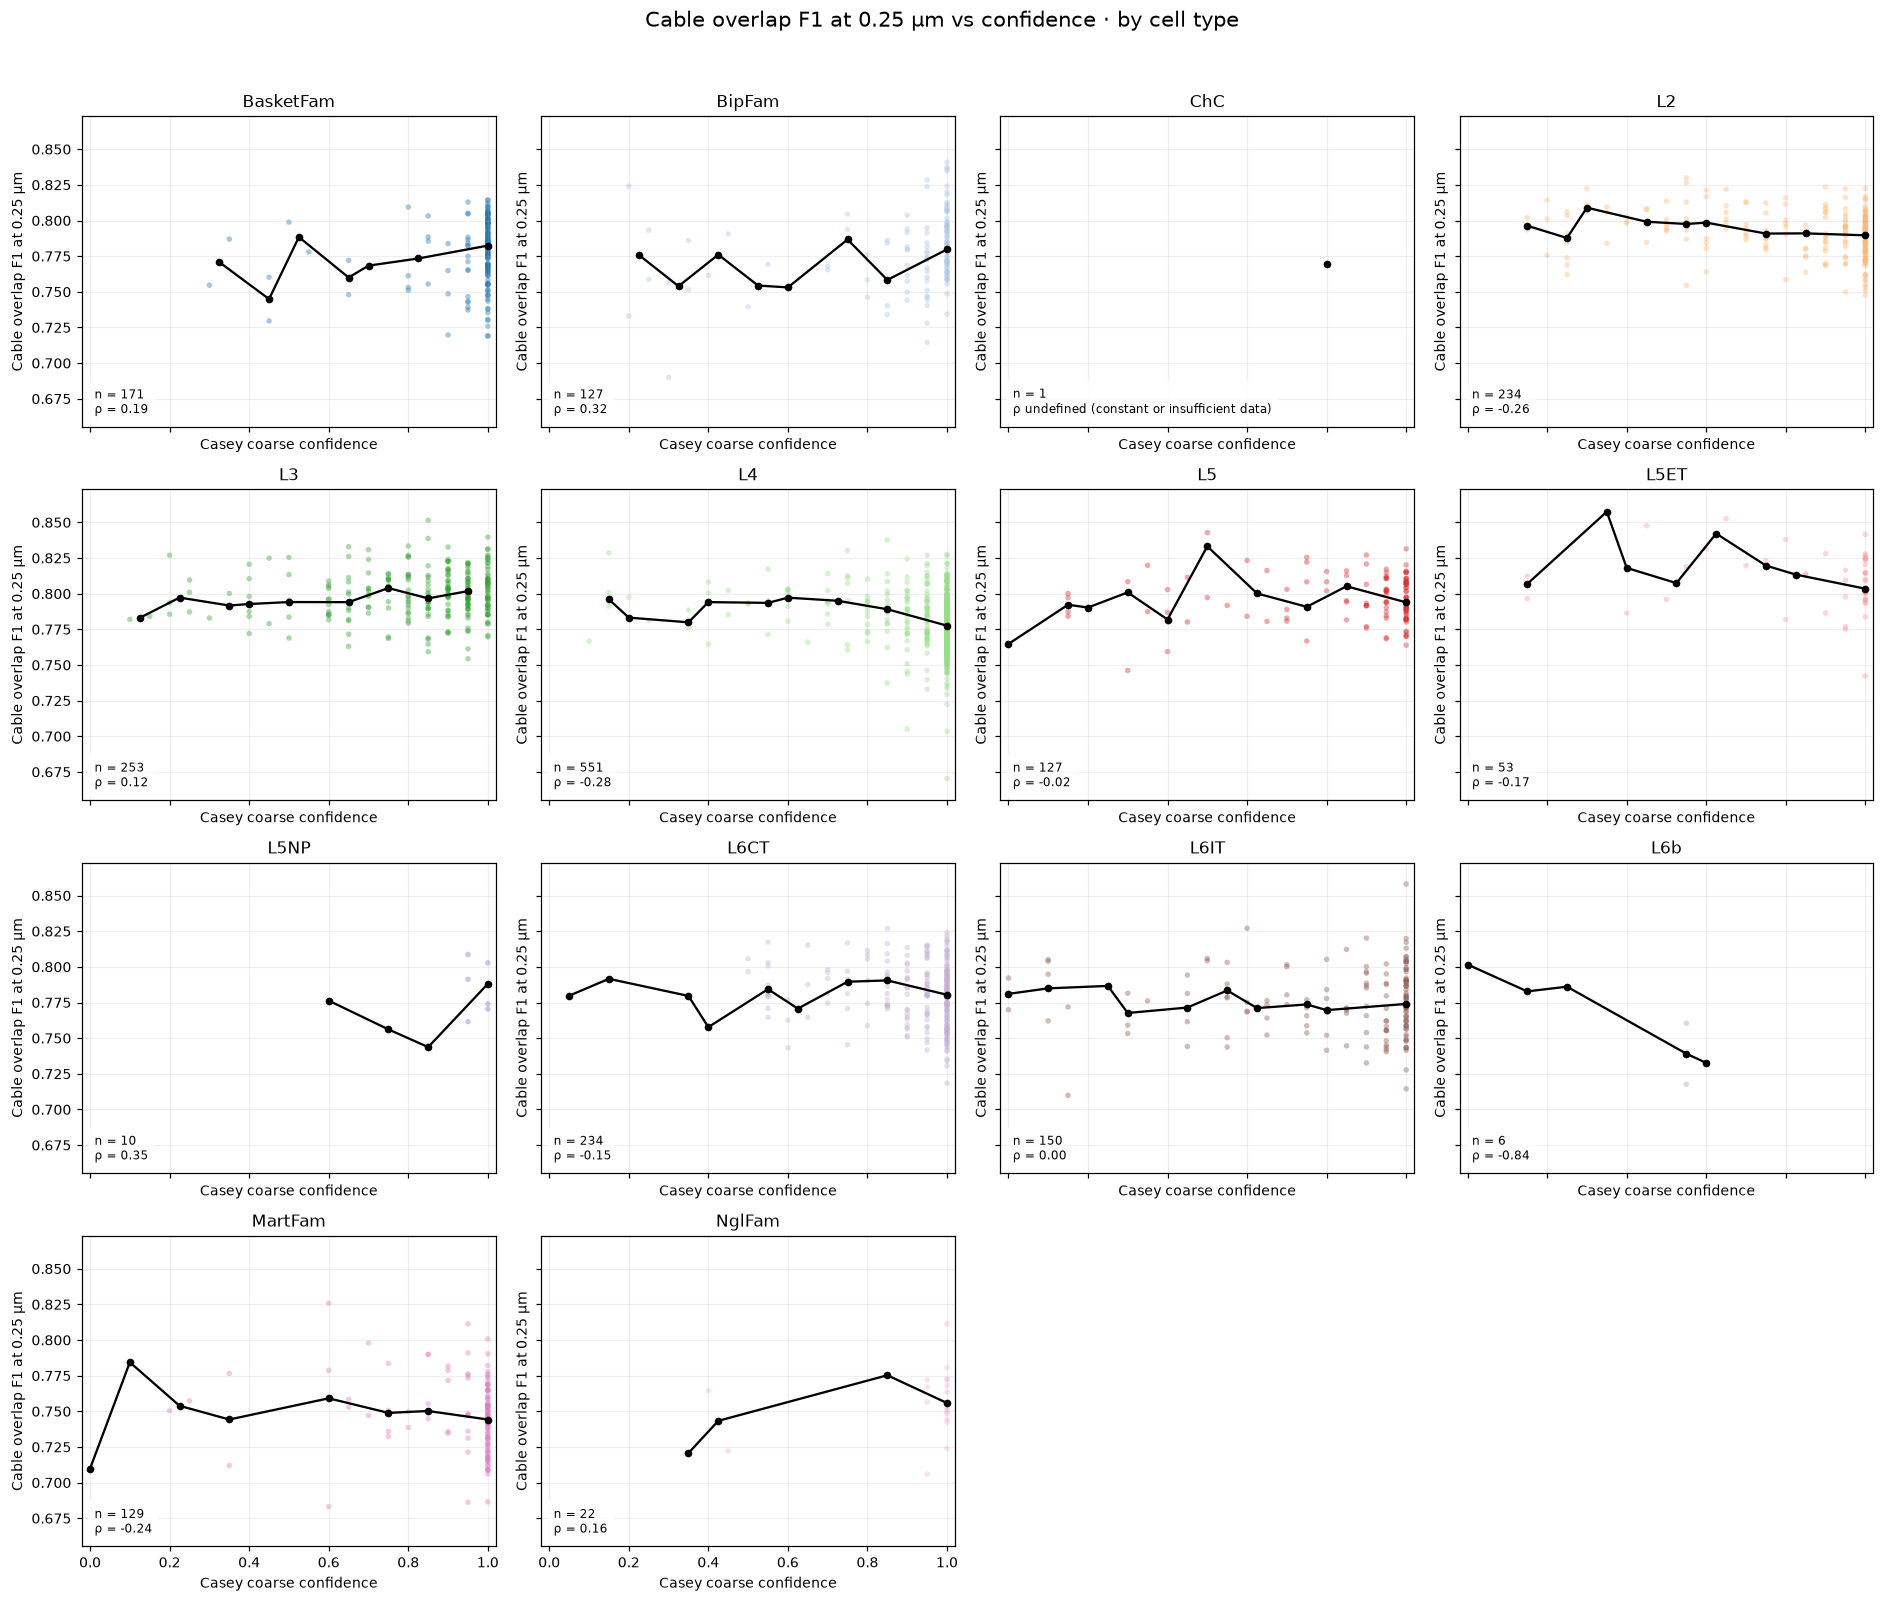

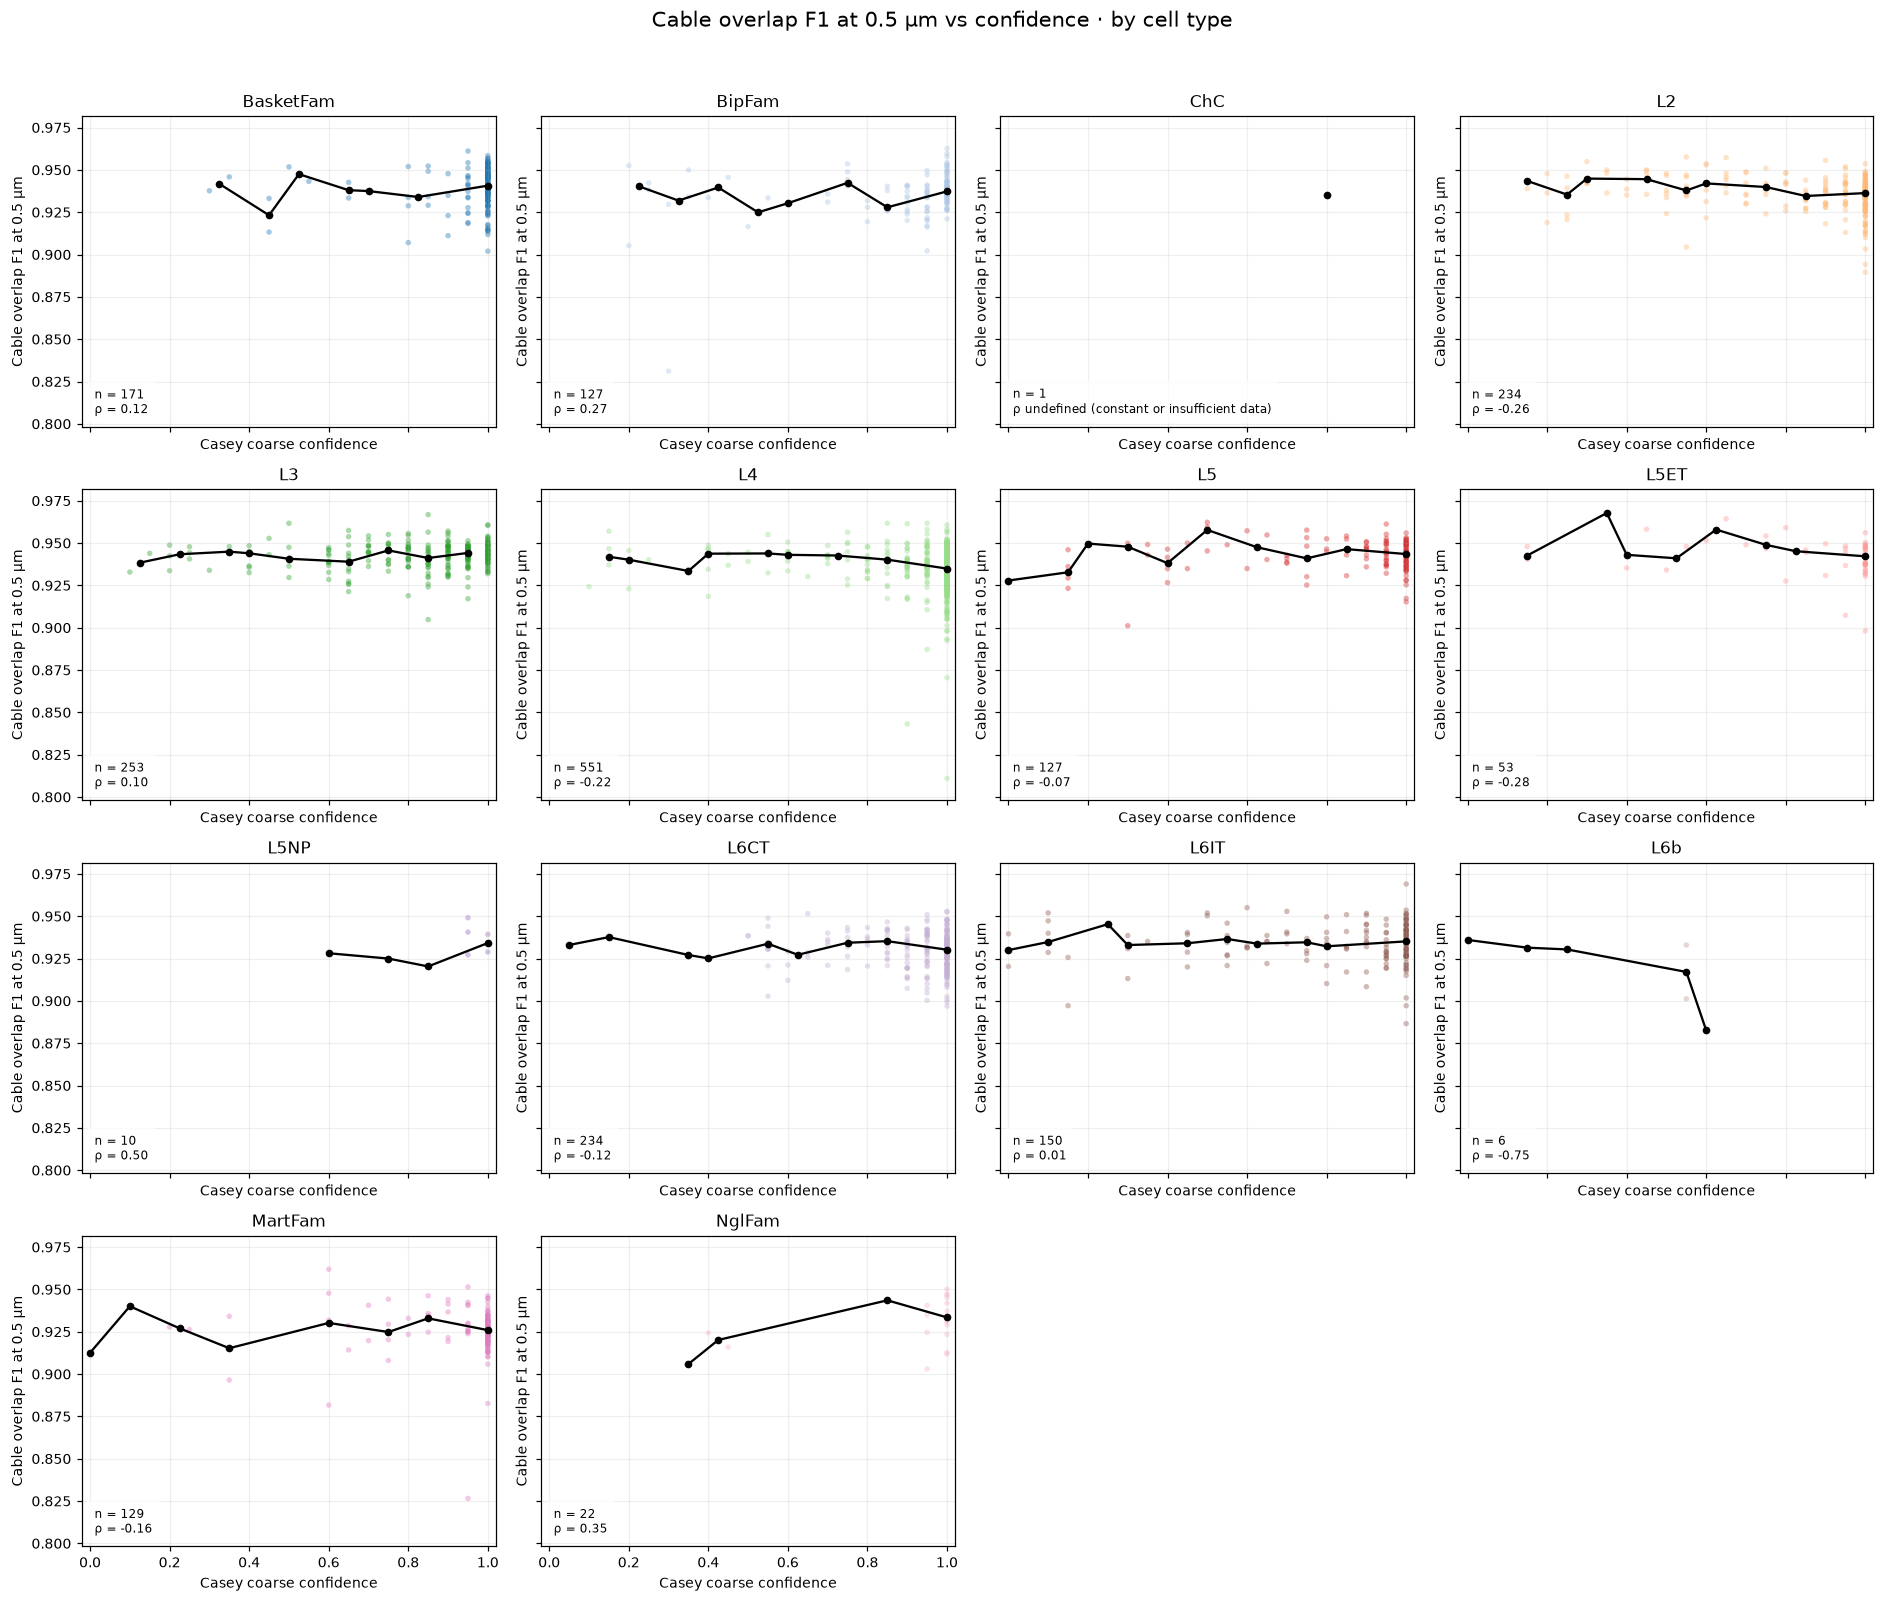

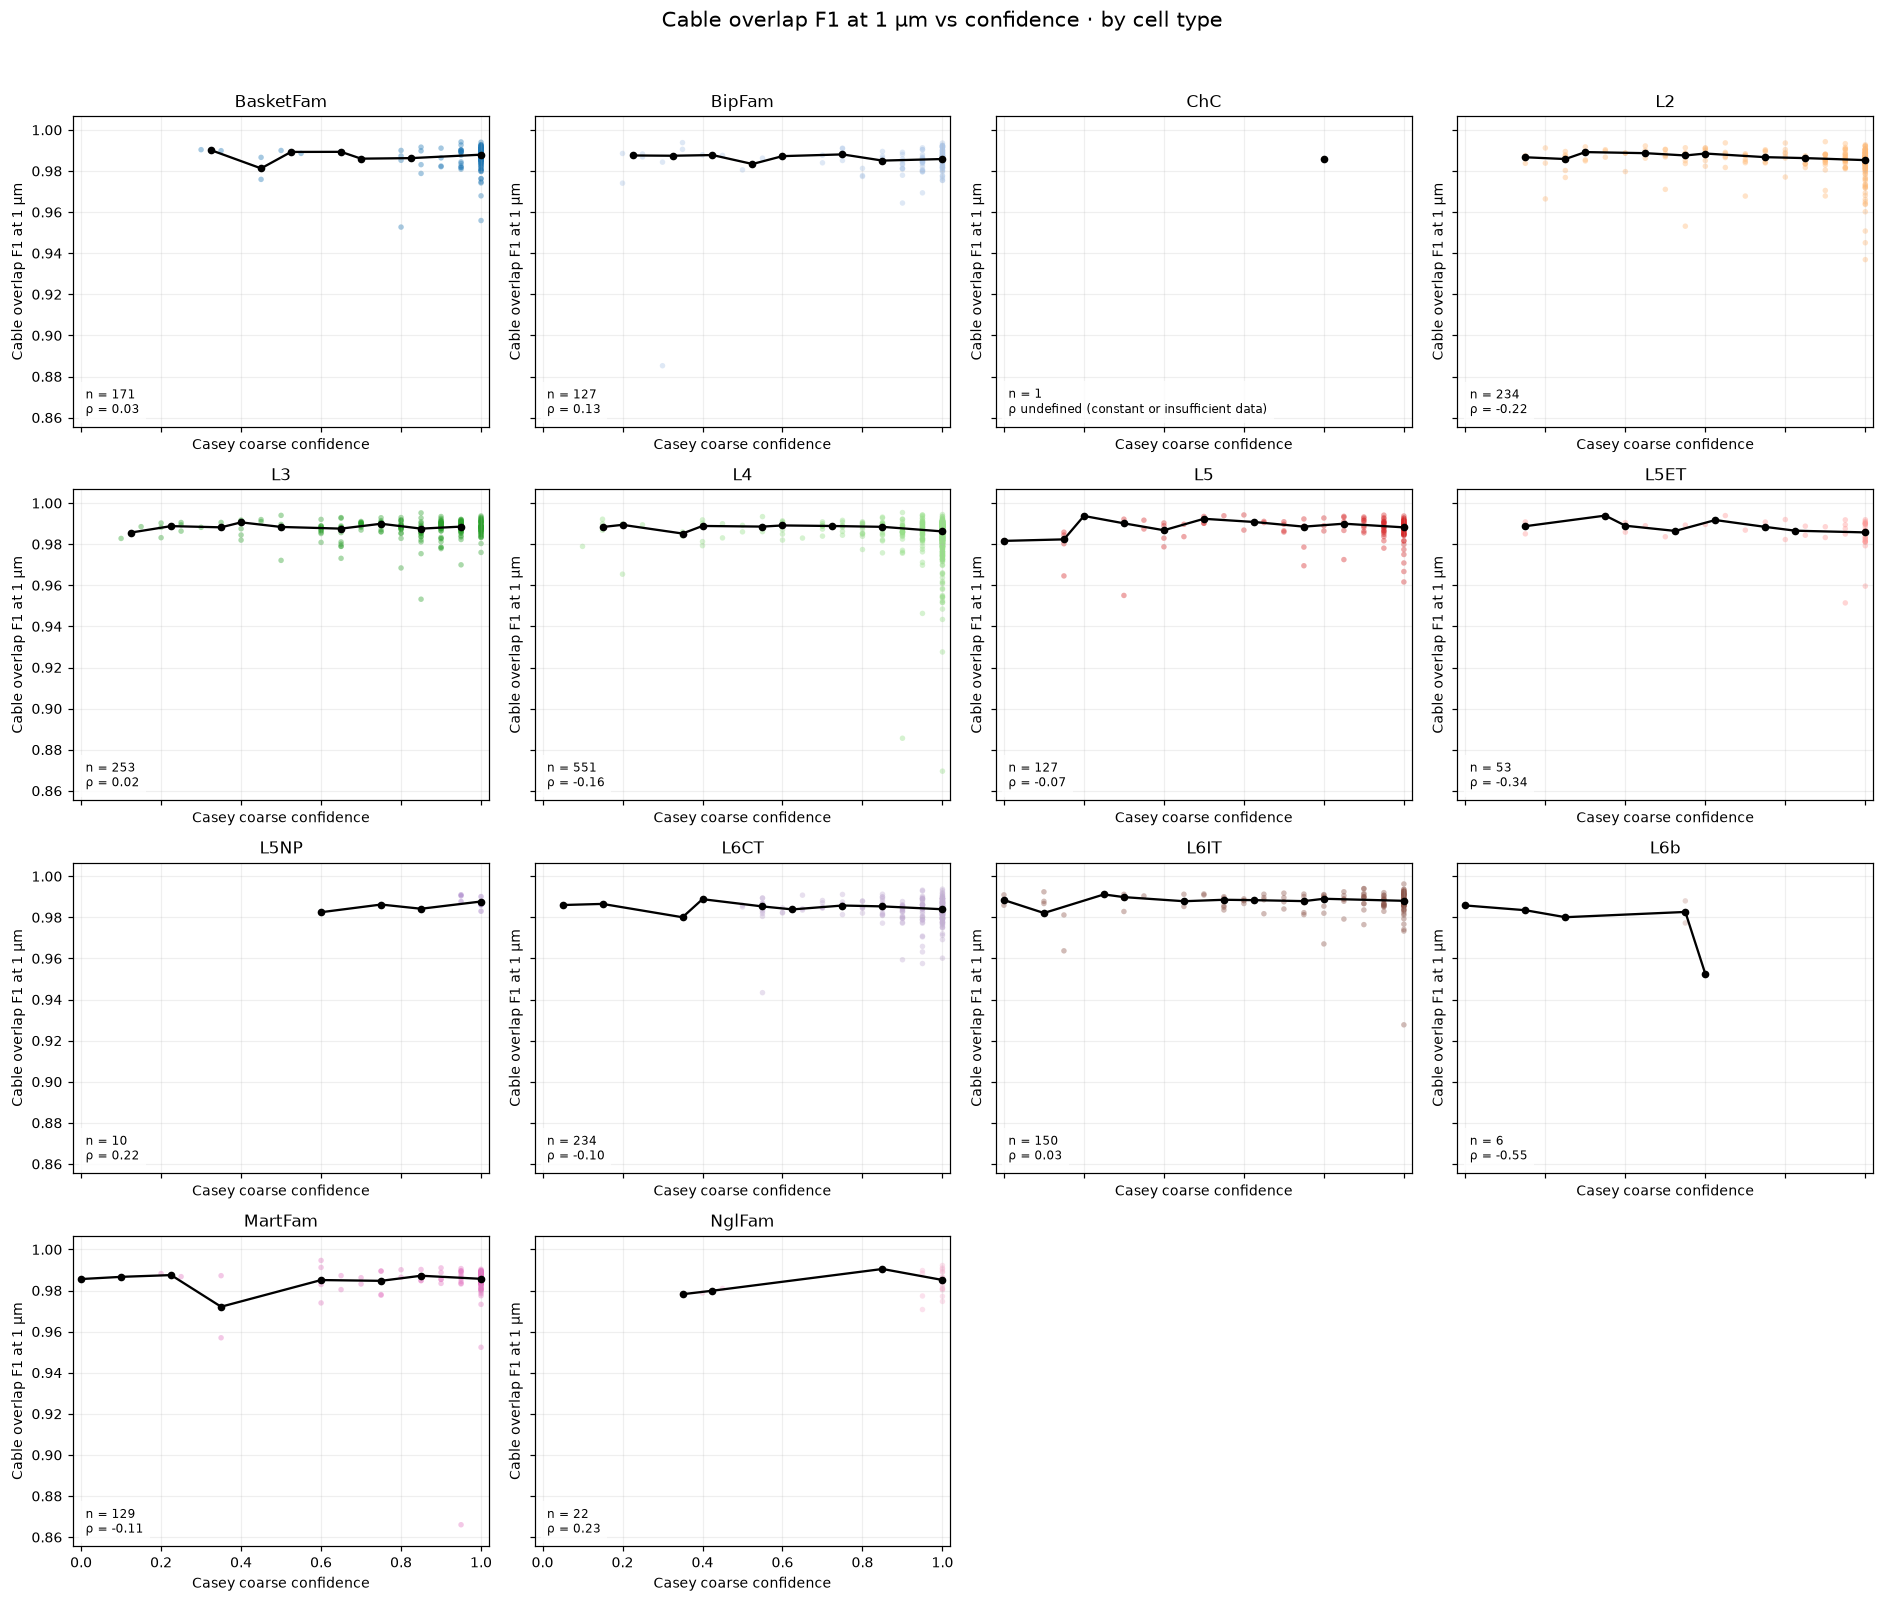

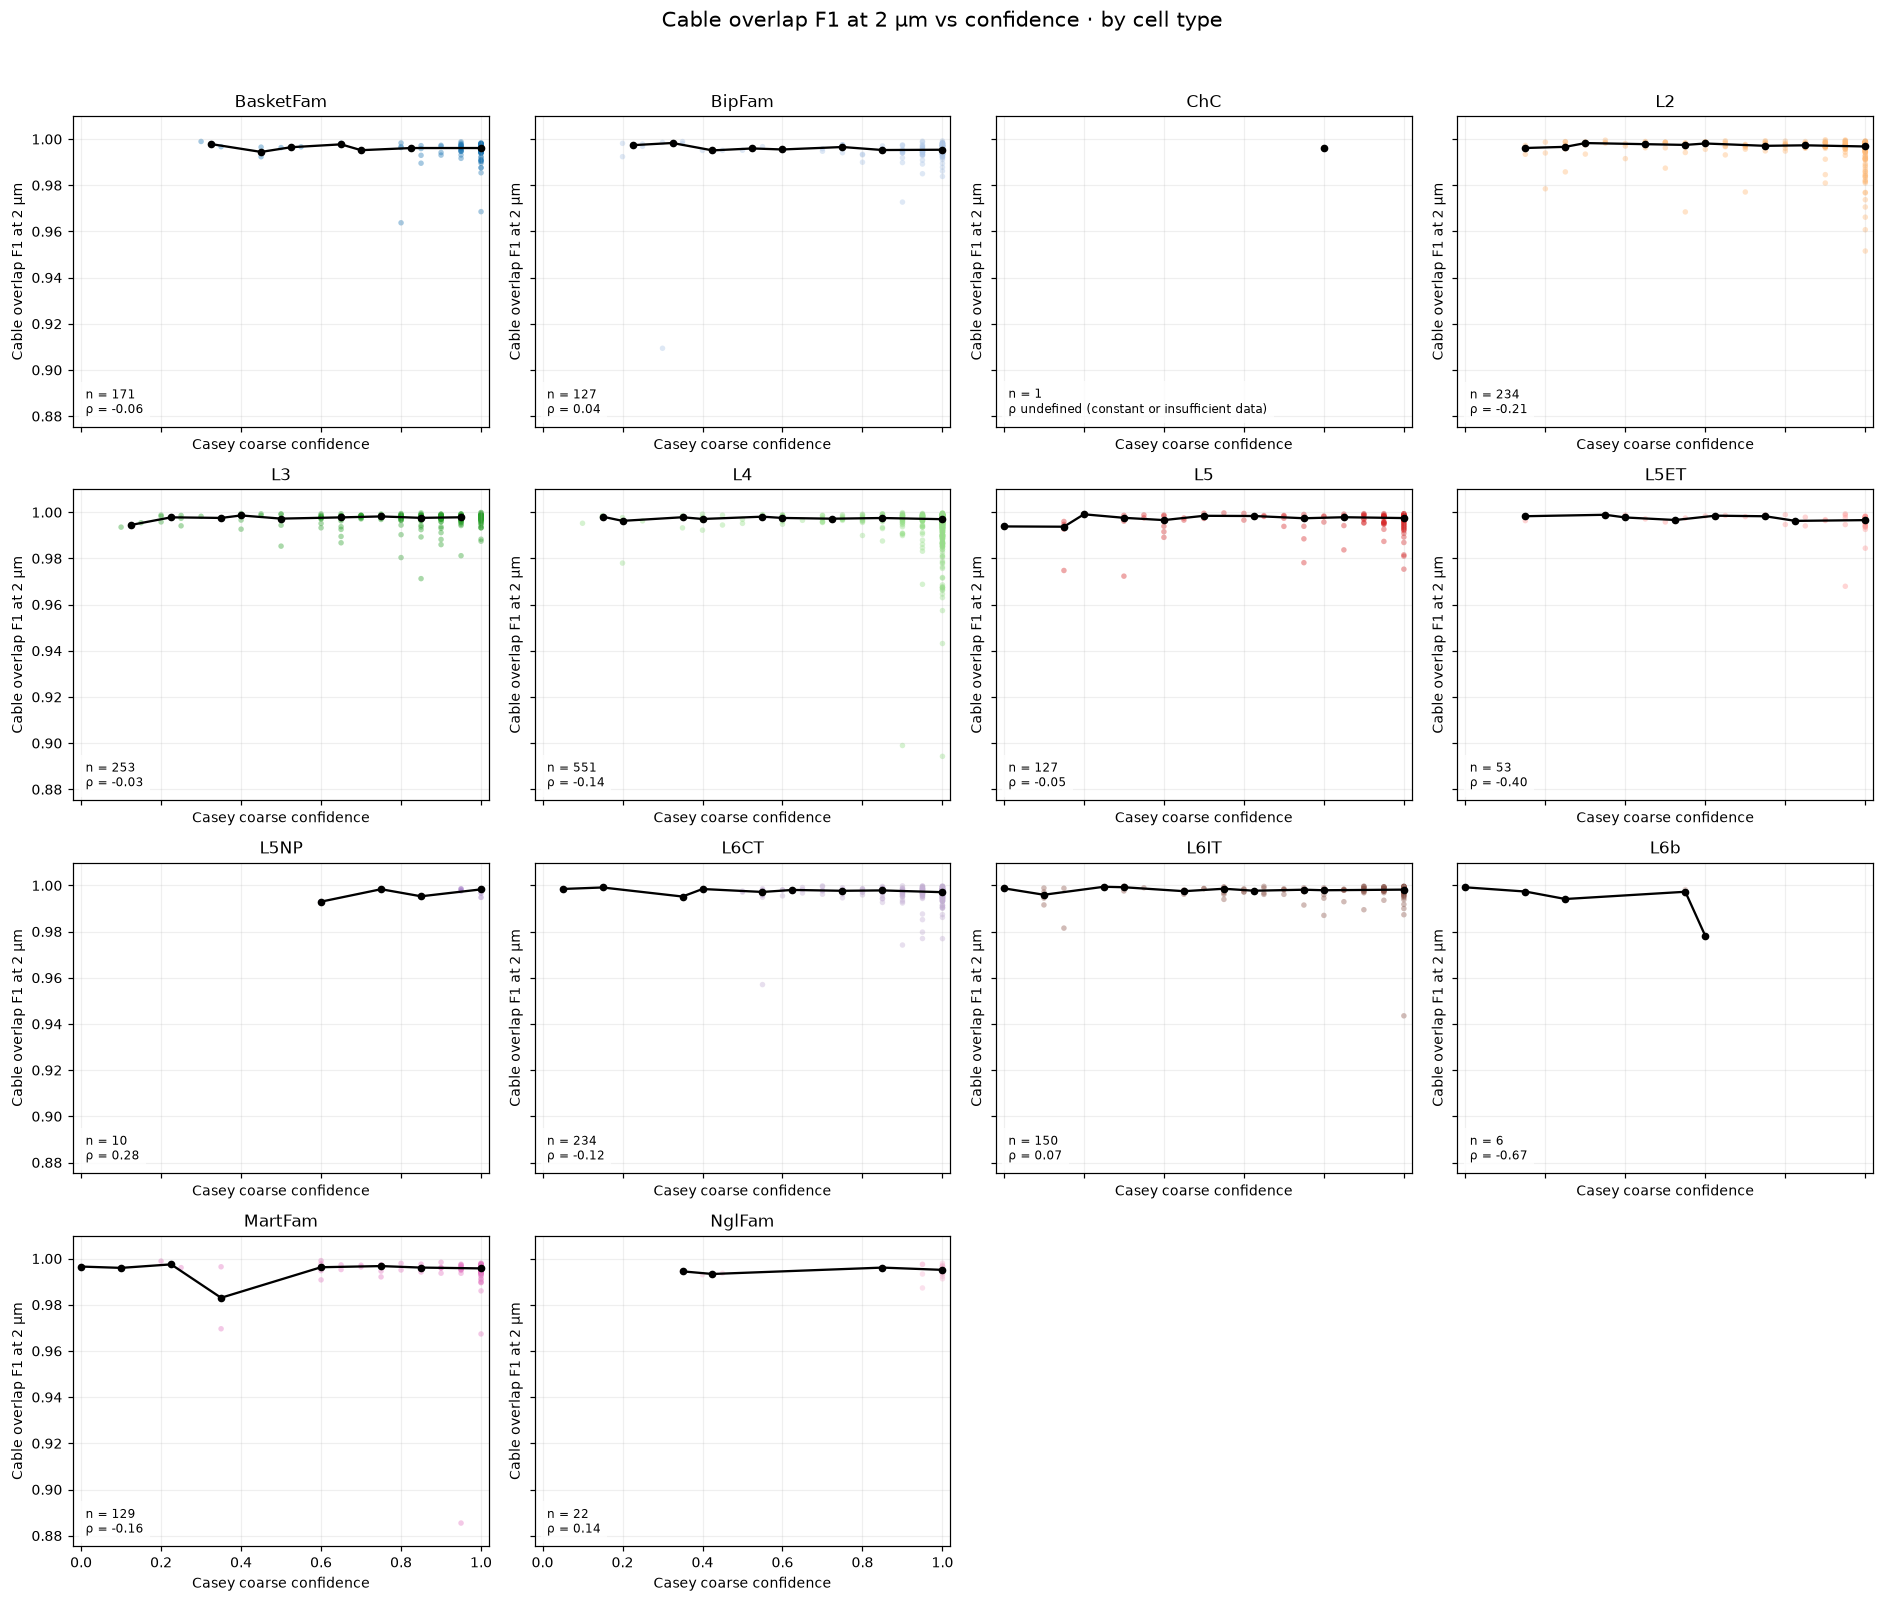

In [3]:
for metric, label in METRICS.items():
    fig = gc.plot_by_cell_type(cells, metric, label, CONFIDENCE_LABEL, BINS)
    if EXPORT:
        gc.save_figure(fig, FIGURE_DIR, "by_type_" + metric.replace(".", "p"))
    plt.show()
    plt.close(fig)

## Numerical summaries and source cells

These are descriptive associations, not a causal test or a reconstruction
accuracy assessment. Both the global and within-type Spearman correlations are
included. Exported tables preserve root IDs as strings. The CSV includes
directional coverage bounds for checking uncertainty near each tolerance.

In [4]:
correlations = gc.correlation_table(cells, METRICS)
display(correlations.pivot(index="cell_type", columns="metric", values="spearman_rho").round(3))
display(cells[["root_id", "cell_type", "confidence", *METRICS]].sort_values("confidence").head(20))
if EXPORT:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    correlations.to_csv(FIGURE_DIR / "correlations.csv", index=False)
    cells.to_csv(FIGURE_DIR / "plotted_cells.csv", index=False)
    print(f"Exported PNG/PDF figures and tables to {FIGURE_DIR}")

metric,f1_0.25um,f1_0.5um,f1_1um,f1_2um,symmetric_mean_um,teasar_cave_cable_ratio
cell_type,,,,,,
All cells,-0.180,-0.124,-0.108,-0.171,0.171,0.186
BasketFam,0.193,0.123,0.035,-0.061,-0.106,-0.256
BipFam,0.321,0.271,0.125,0.043,-0.236,-0.033
ChC,NaN,NaN,NaN,NaN,NaN,NaN
L2,-0.263,-0.262,-0.219,-0.213,0.231,0.158
L3,0.118,0.105,0.025,-0.031,-0.077,-0.105
L4,-0.278,-0.216,-0.155,-0.138,0.230,0.263
L5,-0.017,-0.065,-0.072,-0.051,0.050,-0.082
L5ET,-0.168,-0.281,-0.336,-0.399,0.313,-0.283


,root_id,cell_type,confidence,symmetric_mean_um,teasar_cave_cable_ratio,f1_0.25um,f1_0.5um,f1_1um,f1_2um
75,864691135060772763,MartFam,0.00,0.222165,1.115220,0.709848,0.912568,0.985607,0.996565
312,864691135342823877,L6IT,0.00,0.179102,1.071065,0.792172,0.939647,0.990973,0.998811
1495,864691136033794747,L6IT,0.00,0.193989,1.061733,0.769969,0.920397,0.985922,0.998702
1829,864691136420195223,L5,0.00,0.225769,1.102511,0.764747,0.927885,0.981623,0.993874
1305,864691135919749808,L6b,0.00,0.179289,1.076318,0.801656,0.936026,0.985807,0.999198
980,864691135739004292,L6CT,0.05,0.187109,1.066979,0.779783,0.933037,0.986019,0.998472
1157,864691135808925981,L6IT,0.10,0.251122,1.100092,0.805116,0.947299,0.987811,0.994534
851,864691135646353391,L6IT,0.10,0.199834,1.088238,0.762148,0.928661,0.982132,0.997149
876,864691135662408944,L6IT,0.10,0.169188,1.090855,0.803980,0.951976,0.992443,0.998895
763,864691135577956101,MartFam,0.10,0.190094,1.104857,0.784414,0.940058,0.986678,0.995996


Exported PNG/PDF figures and tables to /orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/analysis/presynaptic/skeleton_comparison/geometry_confidence_figures/casey_coarse_confidence__casey_coarse
